In [4]:
using Distributions,StatsBase,PythonPlot,DataFrames,Optim,NLsolve
PythonPlot.svg(true)
FIG_PATH = "/Users/elevien/Dropbox (Dartmouth College)/Apps/Overleaf/Finite Lineages Plos Journal/paper/figures"

include("branching.jl")
include("drawing.jl")

recursive_draw_lineage (generic function with 1 method)

# Generate population tree 

In [5]:

function generator(init,theta)
    tau_prev = init[2]
    a = 0.1
    tau = max(0.00001,tau_prev*a + (1-a) + sqrt(1-a^2)rand(Normal(0,0.3)))
    time = init[1] + tau
    return hcat([init[1],tau],[time,tau])'
end


theta = []
init = [0,1]
Tmax = 6
function terminate(cell)
    cell.label[end,1]>Tmax
end


root = create_cell(generator(init,theta))
grow_tree!(root,terminate,theta,generator)

# trim the tree
for node in get_leaf_nodes(root)
    node.label[end,1] = Tmax
end

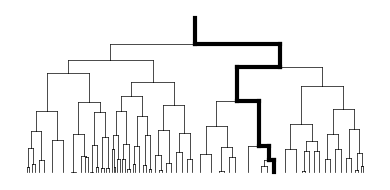

In [19]:

fig,ax = subplots(figsize=(4,2))

x0,y0,depth,h,lw = 0,0,0,5,0.5
recursive_draw_tree(ax,root,x0,y0,depth,h,lw)


ax.spines["top"].set_visible(false)
ax.spines["right"].set_visible(false)
ax.spines["bottom"].set_visible(false)
ax.spines["left"].set_visible(false)
tick_params(left = false, right = false , labelleft = false,labelbottom = false, bottom = false) 

tight_layout()

lw = 3
x,y,depth = recursive_draw_lineage(ax,root,x0,y0,0,h,lw,"k")

savefig(FIG_PATH*"/intro_tree.pdf")
fig

# Generate simulated lineages

In [7]:
θ = (σM=0.2,σλ = 0.14)


function generate_adder_lineage(θ,n)
    M = zeros(n+1)

    M[1] = 1
    for k in 2:(n+1)
        M[k] = (M[k-1]  + 1)/2 + rand(Normal(0,θ.σM))/2
    end
    G = rand(Normal(1,θ.σλ),n+1)
    T = log.(2M[2:end] ./ (M[1:end-1])) ./G[1:end-1]
    return DataFrame(hcat(M[1:end-1],G[1:end-1],T,cumsum(T)),[:M,:λ,:τ,:t])
end

dfs = [generate_adder_lineage(θ,200) for j in 1:200];

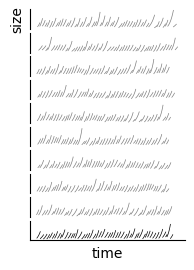

In [11]:

nrows = 10
fig,axs = subplots(figsize=(2,3),nrows=nrows,sharex=true,sharey=true)
for k in 1:nrows
    ax = axs[k-1]
    df = dfs[k][1:50,:]
    for i in 1:(length(df.M)-1)
        trng = collect(df.t[i]:0.01:df.t[i+1]) 
        #ax.vlines([df.t[i+1]],df.M[i+1],exp.(df.τ[i] *df.λ[i])*df.M[i],color="k",lw=0.4,linestyle="--")
        ax.plot(trng,df.M[i] .* exp.((trng .- trng[1]) .* df.λ[i]),"-",lw=0.5,color= (k == nrows) ? "k" : "gray")
    end
    ax.spines["right"].set_visible(false)
    ax.spines["top"].set_visible(false)
    ax.spines["bottom"].set_visible(false)
    ax.tick_params(bottom = false) 
    ax.tick_params(axis="both", left=false, top=false, right=false, bottom=false, labelleft=false, labeltop=false, labelright=false, labelbottom=false) 
    # ax.vlines([34],0,3,color="C4")    
    # ax.vlines([df[46,:t]],0,3,color="C1") 
    
end
axs[0].set_ylabel("size")
axs[length(axs)-1].spines["bottom"].set_visible(true)
axs[length(axs)-1].set_xlabel("time")


savefig(FIG_PATH*"/intro_lineages.pdf",bbox_inches="tight")

fig

sys:1: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


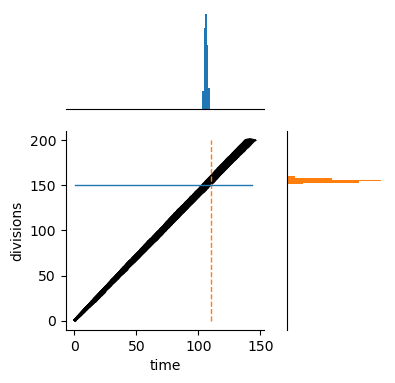

In [37]:
fig = figure(figsize=(4, 4))
gs = fig.add_gridspec(2, 2,  width_ratios=(4, 2), height_ratios=(2, 4),
                      left=0.1, right=0.9, bottom=0.1, top=0.9,
                      wspace=0.15, hspace=0.15)
                    
ax = fig.add_subplot(gs[1, 0])
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax)
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax)

# -------------------------------------------------------
for k in 1:length(dfs)
    df = dfs[k]
    ax.plot(df.t,(1:length(df.t)),"k-",markersize=0.1)
end
ax.vlines([110],0,200,linestyle="--",color="C1",lw=1)
ax.plot(dfs[1].t,150ones(length(dfs[1].t)),"C0-",lw=1)
ax.spines["right"].set_visible(false)
ax.spines["top"].set_visible(false)

# -------------------------------------------------------
ax_histx.tick_params(axis="both", left=false, top=false, right=false, bottom=false, labelleft=false, labeltop=false, labelright=false, labelbottom=false)     
ax_histy.tick_params(axis="both", left=false, top=false, right=false, bottom=false, labelleft=false, labeltop=false, labelright=false, labelbottom=false)
ax_histx.spines["right"].set_visible(false)
ax_histx.spines["top"].set_visible(false)
ax_histx.spines["left"].set_visible(false)
ax_histy.spines["right"].set_visible(false)
ax_histy.spines["top"].set_visible(false)
ax_histy.spines["bottom"].set_visible(false)

#bins = collect(100:1:150)
h,x = ax_histx.hist([df.t[150] for df in dfs],5,color="C0",density=true)
#x = (bins[1:end-1] .+ bins[2:end]) ./2
#ax_histx.plot(x,h,"C5-")


ax_histy.hist([length(df[df.t .< 110,:].t) for df in dfs],5,color="C1",orientation="horizontal",density=true)
ax.set_xlabel("time")
ax.set_ylabel("divisions")

tight_layout()

savefig(FIG_PATH*"/intro_hist.pdf",bbox_inches="tight")
fig

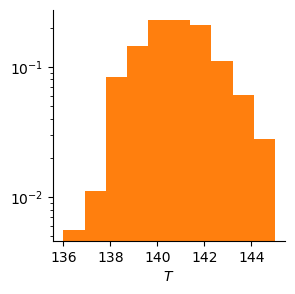

In [35]:
fig,ax = subplots(figsize=(3,3))
ax.hist([length(df[df.t .< 100,:].t) for df in dfs],10,color="C1",density=true)
ax.semilogy()
ax.spines["right"].set_visible(false)
ax.spines["top"].set_visible(false)
ax.set_xlabel(L"$T$")
#savefig(FIG_PATH*"/intro_hist2.pdf",bbox_inches="tight")
fig

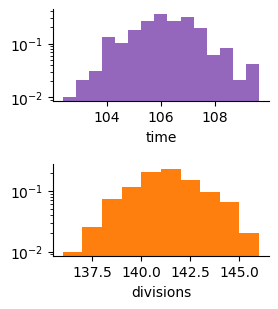

In [143]:
fig,axs = subplots(figsize=(3,3),nrows=2)

ax = axs[0]
ax.hist([df.t[150] for df in dfs],15,color="C4",density=true)
ax.set_xlabel("time")
ax.semilogy()
ax.spines["right"].set_visible(false)
ax.spines["top"].set_visible(false)
tight_layout()
ax = axs[1]
ax.hist([length(df[df.t .< 100,:].t) for df in dfs],10,color="C1",density=true)
ax.semilogy()
ax.spines["right"].set_visible(false)
ax.spines["top"].set_visible(false)
ax.set_xlabel("divisions")
savefig(FIG_PATH*"/intro_hist2.pdf")
fig

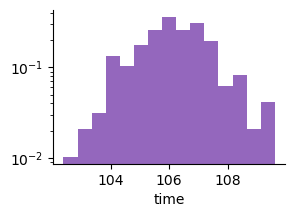

In [147]:
fig,ax = subplots(figsize=(3,2))

ax.hist([df.t[150] for df in dfs],15,color="C4",density=true)
ax.set_xlabel("time")
ax.semilogy()
ax.spines["right"].set_visible(false)
ax.spines["top"].set_visible(false)
savefig(FIG_PATH*"/intro_hist21.pdf",bbox_inches="tight")
fig